<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [32]:
import pandas as pd, numpy as np

data = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")

sum_stats_table =  data[["fare_amount", "tip_amount", "tolls_amount", "total_amount"]].describe()

sum_stats_table


,fare_amount,tip_amount,tolls_amount,total_amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,15.106313,2.634494,0.623447,22.564659
std,13.954762,3.409800,6.437507,19.209255
min,-52.000000,0.000000,-6.120000,-65.920000
25%,7.000000,0.000000,0.000000,12.375000
50%,10.000000,2.000000,0.000000,16.300000
75%,16.000000,3.250000,0.000000,22.880000
max,176.000000,43.000000,612.000000,671.800000


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [31]:
max_row = data.loc[data["trip_distance"].idxmax(), ["fare_amount", "tip_amount", "tolls_amount", "total_amount"]]
max_row[["fare_amount", "tip_amount", "tolls_amount", "total_amount"]]

fare_amount      176.0
tip_amount       18.29
tolls_amount      6.12
total_amount    201.21
Name: 8338, dtype: object

<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [30]:
land = pd.read_csv("data/Meteorite_Landings.csv")
land = land.rename(columns={"mass (g)": "mass"}).iloc[:, :-3]
sort_land = land.sort_values(by = "mass", ascending= False)
sort_land

,name,id,nametype,recclass,mass,fall,year
16392,Hoba,11890,Valid,"Iron, IVB",60000000.0,Found,01/01/1920 12:00:00 AM
5373,Cape York,5262,Valid,"Iron, IIIAB",58200000.0,Found,01/01/1818 12:00:00 AM
5365,Campo del Cielo,5247,Valid,"Iron, IAB-MG",50000000.0,Found,12/22/1575 12:00:00 AM
5370,Canyon Diablo,5257,Valid,"Iron, IAB-MG",30000000.0,Found,01/01/1891 12:00:00 AM
3455,Armanty,2335,Valid,"Iron, IIIE",28000000.0,Found,01/01/1898 12:00:00 AM
...,...,...,...,...,...,...,...
38282,Wei-hui-fu (a),24231,Valid,Iron,NaN,Found,01/01/1931 12:00:00 AM
38283,Wei-hui-fu (b),24232,Valid,Iron,NaN,Found,01/01/1931 12:00:00 AM
38285,Weiyuan,24233,Valid,Mesosiderite,NaN,Found,01/01/1978 12:00:00 AM
41472,Yamato 792768,28117,Valid,CM2,NaN,Found,01/01/1979 12:00:00 AM


<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [26]:
meteor = pd.read_csv("data/Meteorite_Landings.csv")
meteor['year'] = meteor['year'].str[6:10]
meteor['year'] = pd.to_numeric(meteor['year'])
meteor['before_after_1970'] = np.where(meteor['year'] < 1970, 'Before 1970', '1970 or Later')
subsection = meteor.loc[(meteor["id"] >= 10036) & (meteor["id"] <= 10040)]
subsection

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation,before_after_1970
282,Enshi,10038,Valid,H5,8000.0,Fell,1974.0,30.30000,109.50000,"(30.3, 109.5)",1970 or Later
283,Ensisheim,10039,Valid,LL6,127000.0,Fell,1491.0,47.86667,7.35000,"(47.86667, 7.35)",Before 1970
11650,Enigma,10036,Valid,H4,94.0,Found,1967.0,31.33333,-82.31667,"(31.33333, -82.31667)",Before 1970
11651,Enon,10037,Valid,"Iron, ungrouped",763.0,Found,1883.0,39.86667,-83.95000,"(39.86667, -83.95)",Before 1970


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [29]:
#There is a year 2101, which has not happened yet
meteor = pd.read_csv("data/Meteorite_Landings.csv")
meteor['year'] = meteor['year'].str[6:10]
meteor['year'] = pd.to_numeric(meteor['year'])
sort_meteor = meteor.sort_values(by = "year", ascending=False)

sort_meteor.head()

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
30682,Northwest Africa 7701,57150,Valid,CK6,55.0,Found,2101.0,0.0,0.0,"(0.0, 0.0)"
30780,Northwest Africa 7862,57426,Valid,L4/5,317.0,Found,2013.0,0.0,0.0,"(0.0, 0.0)"
30776,Northwest Africa 7857,57422,Valid,LL6,246.0,Found,2013.0,0.0,0.0,"(0.0, 0.0)"
30777,Northwest Africa 7858,57423,Valid,H4,459.0,Found,2013.0,0.0,0.0,"(0.0, 0.0)"
30774,Northwest Africa 7855,57420,Valid,H4,916.0,Found,2013.0,0.0,0.0,"(0.0, 0.0)"


There's a meteorite that was reportedly found in the future:

In [28]:
# The year 2101
sort_meteor.head()

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
30682,Northwest Africa 7701,57150,Valid,CK6,55.0,Found,2101.0,0.0,0.0,"(0.0, 0.0)"
30780,Northwest Africa 7862,57426,Valid,L4/5,317.0,Found,2013.0,0.0,0.0,"(0.0, 0.0)"
30776,Northwest Africa 7857,57422,Valid,LL6,246.0,Found,2013.0,0.0,0.0,"(0.0, 0.0)"
30777,Northwest Africa 7858,57423,Valid,H4,459.0,Found,2013.0,0.0,0.0,"(0.0, 0.0)"
30774,Northwest Africa 7855,57420,Valid,H4,916.0,Found,2013.0,0.0,0.0,"(0.0, 0.0)"


_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [23]:
trip_time = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")

trip_time['dropoff'] = pd.to_datetime(trip_time['tpep_dropoff_datetime'])

trip_time.set_index('dropoff', inplace=True)

hourly_data = trip_time.resample('H').agg({
    'trip_distance': 'sum',
    'fare_amount': 'sum',
    'tolls_amount': 'sum',
    'tip_amount': 'sum'
})

top5_tips = hourly_data.sort_values(by='tip_amount', ascending=False).head(5)
print(top5_tips)

                     trip_distance  fare_amount  tolls_amount  tip_amount
dropoff                                                                  
2019-10-23 16:00:00       10676.95     67797.76        699.04    12228.64
2019-10-23 17:00:00       16052.83     70131.91       4044.04    12044.03
2019-10-23 18:00:00        3104.56     11565.56       1454.67     1907.64
2019-10-23 15:00:00          14.34       213.50          0.00       51.75
2019-10-23 19:00:00          98.59       268.00         24.48       25.74


/tmp/ipykernel_29273/2064638444.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = trip_time.resample('H').agg({


<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

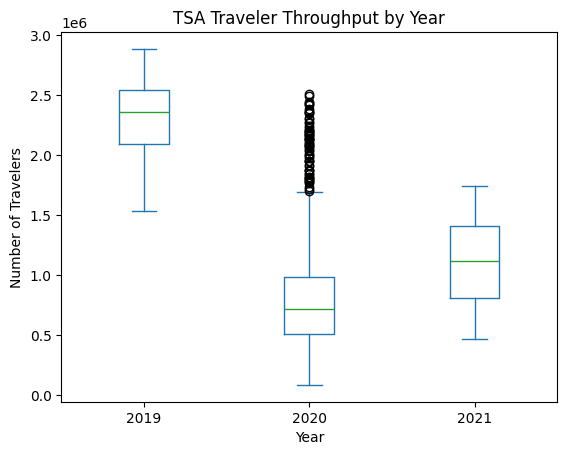

In [17]:
tsa_box = pd.read_csv("data/tsa_melted_holiday_travel.csv")

data_pivot = tsa_box.pivot(columns='year', values='travelers')

data_pivot.plot(kind='box')
plt.title("TSA Traveler Throughput by Year")
plt.ylabel("Number of Travelers")
plt.xlabel("Year")
plt.show()

<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

/tmp/ipykernel_29273/3630331029.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tsa_2019['date'] = pd.to_datetime(tsa_2019['date'])
/tmp/ipykernel_29273/3630331029.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tsa_2019['month'] = tsa_2019['date'].dt.month
/tmp/ipykernel_29273/3630331029.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

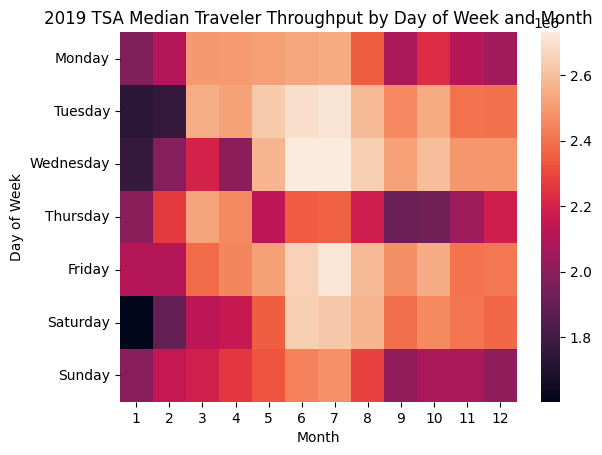

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
tsa_holiday = pd.read_csv("data/tsa_melted_holiday_travel.csv")
tsa_2019 = tsa_holiday[tsa_holiday['year'] == 2019]
tsa_2019['date'] = pd.to_datetime(tsa_2019['date'])
tsa_2019['month'] = tsa_2019['date'].dt.month
tsa_2019['day_of_week'] = tsa_2019['date'].dt.day_name() 

heatmap_data = tsa_2019.pivot_table(index='day_of_week', columns='month', values='travelers', aggfunc='median')

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

sns.heatmap(heatmap_data)
plt.title("2019 TSA Median Traveler Throughput by Day of Week and Month")
plt.xlabel("Month")
plt.ylabel("Day of Week")
plt.show()